<a href="https://colab.research.google.com/github/sauravpatil045/MLOPS1.THIRD-YEAR/blob/main/MIL5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

In [78]:
df =  pd.read_csv("Non_linear_SVM_Dataset.csv")
df

,X1,X2,Y
0,0.830858,-0.334342,1.0
1,0.991710,0.879000,0.0
2,1.107245,-0.470344,1.0
3,-0.140899,1.033148,0.0
4,0.405592,1.328529,0.0
...,...,...,...
495,0.265123,1.023197,0.0
496,0.193576,-0.011663,1.0
497,0.345548,-0.128434,1.0
498,1.403890,-0.466993,1.0


In [79]:
df.info() #Structure of Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      500 non-null    float64
 1   X2      500 non-null    float64
 2   Y       500 non-null    float64
dtypes: float64(3)
memory usage: 11.8 KB


In [80]:
Y = df["Y"] #Output
X = df.drop(columns='Y') #Input
X.head()

,X1,X2
0,0.830858,-0.334342
1,0.991710,0.879000
2,1.107245,-0.470344
3,-0.140899,1.033148
4,0.405592,1.328529


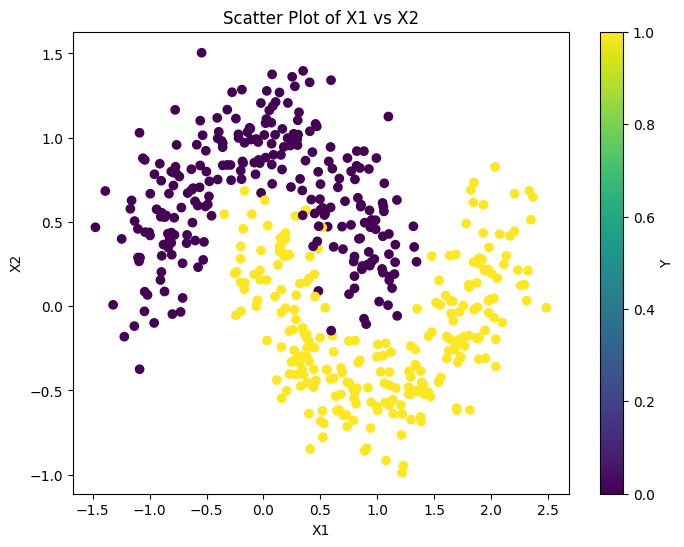

In [81]:
# Assuming X1 and X2 are the first  two columns of x
plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=Y, cmap='viridis')#use Y for colourmapping
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Scatter Plot of X1 vs X2")
plt.colorbar(label="Y")
plt.show()

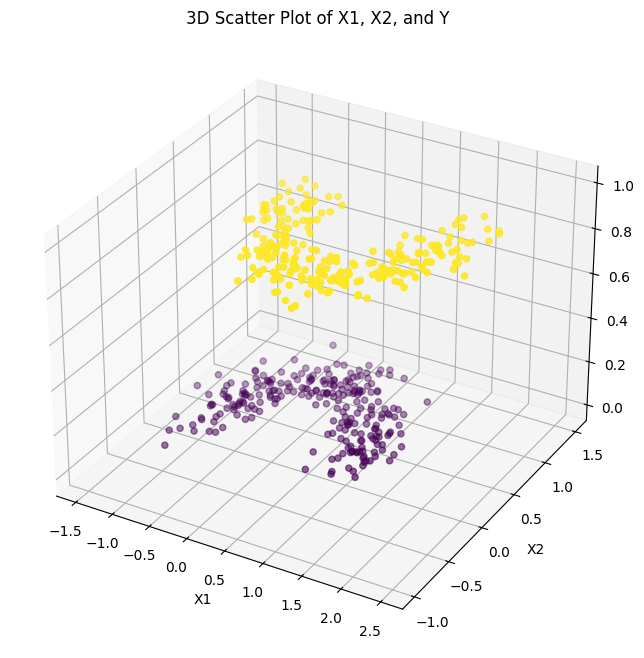

In [82]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X['X1'], X['X2'], Y, c=Y, cmap='viridis')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
ax.set_title('3D Scatter Plot of X1, X2, and Y')
plt.show()

In [83]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Test data=30%, Training Data=70%

In [84]:
# Linear Classifier
from sklearn.svm import SVC
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

SVC(kernel='linear')

In [85]:
from sklearn.metrics import accuracy_score
y_pred_linear = linear_svm.predict(X_test)
print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))

Linear SVM Accuracy: 0.85


In [86]:
# RBF SVM
rbf_svm = SVC(kernel='rbf', C=10, gamma='scale')
rbf_svm.fit(X_train, y_train)
y_pred_rbf = rbf_svm.predict(X_test)
print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf))

RBF SVM Accuracy: 0.98


In [87]:
# Polynomial SVM
poly_svm = SVC(kernel='poly', degree=2, C=10)
poly_svm.fit(X_train, y_train)
y_pred_poly = poly_svm.predict(X_test)
print("Polynomial SVM Accuracy:", accuracy_score(y_test, y_pred_poly))

Polynomial SVM Accuracy: 0.78


In [88]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
params = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001]}
grid = GridSearchCV(SVC(kernel='rbf'), params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print("\nBest Parameters:")
print(grid.best_params_)


Best Parameters:
{'C': 1, 'gamma': 1}


In [89]:
# Best Model
from sklearn.metrics import classification_report
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("\nTuned RBF SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Tuned RBF SVM Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.97        43
         1.0       1.00      0.95      0.97        57

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

